In [1]:
import os
import time
import json
import pickle
import pandas as pd
import numpy as np

from datetime import datetime
from tqdm import tqdm
from dotenv import load_dotenv
from pathlib import Path

In [2]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

from huggingface_hub import login
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
from vllm import LLM, SamplingParams

import mlflow
from databricks.sdk import WorkspaceClient

/opt/conda/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
2025-12-12 19:30:23.512692: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-12 19:30:23.525949: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-12 19:30:23.530060: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-12 19:30:23.540197: I tensorflow/core/platfor

INFO 12-12 19:30:25 [__init__.py:239] Automatically detected platform cuda.


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

Define path variables

In [4]:
model_id = "allenai/longformer-base-4096"

classification_type = "mean_pooling_embedding"
model_name = "longformer-base-4096"
developer_initials = "JP"

In [5]:
current_dir = Path.cwd()
env_path = current_dir.parent.parent / "conf" / "local" / ".env"
results_path = current_dir.parent.parent / "results" / "transformer"

train_data_full_cleaned_path = current_dir.parent.parent / "data" /  "01_processed" / "pan20-authorship-verification-training-large-cleaned.jsonl"
test_data_full_cleaned_path = current_dir.parent.parent / "data" /  "01_processed" / "pan21-authorship-verification-test-cleaned.jsonl"

Load environment variables
Get access to HuggingFace

In [6]:
load_dotenv(env_path)
huggingface_acess_token = os.getenv("huggingface_jp")

Connect to databricks for logging results

In [7]:
w = WorkspaceClient()   
print("Connected to:", w.config.host)

mlflow.set_tracking_uri("databricks")

Connected to: https://dbc-1ea3ad0e-f504.cloud.databricks.com


What are GPU are the experiments run on

In [8]:
!nvidia-smi

Fri Dec 12 19:30:28 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40                     Off |   00000000:A3:00.0 Off |                    0 |
|  0%   44C    P8             36W /  300W |       0MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [9]:
running_on_gpu = torch.cuda.is_available()

In [10]:
if running_on_gpu:
    gpu_name = torch.cuda.get_device_name(0)
    gpu_props = torch.cuda.get_device_properties(0)
    gpu_vram_gb = round(gpu_props.total_memory / (1024**3), 2)
else:
    gpu_name = "CPU"
    gpu_props = "N/A"
    gpu_vram_gb = 0

Empty the GPU from previous experiments

In [11]:
import gc
import torch
torch.cuda.empty_cache()
gc.collect()

144

In [12]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

Classification threshold constant specification

In [13]:
thresholds = [x/1000 for x in range(900, 999)]

# Load data

Training dataset size for tuning

In [14]:
train_tuning_size = 19_999

#### Load training data

In [15]:
train_data_file_size = os.path.getsize(train_data_full_cleaned_path)
train_data = []

with open(train_data_full_cleaned_path, 'r') as f:
    with tqdm(total=train_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            train_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(train_data)} items.")

Loading data: 100%|██████████| 11.3G/11.3G [00:24<00:00, 470MB/s]


Successfully loaded 273301 items.


In [16]:
train_data_df = pd.DataFrame(train_data)

#### Create a subset of training data for finding the threshold

In [17]:
train_tuning_data_df = train_data_df.sample(n=train_tuning_size, random_state=42)
train_tuning_data_df = train_tuning_data_df.reset_index(drop=True)
train_tuning_data_df.head()

,id,pair,same
0,1c4a05b6-dabb-5a9d-9e6a-7709b07d8dff,[comes home at about onethirty that night Case...,True
1,aff2cdfb-625d-5fa7-acb8-a0ff9876b34f,"[He rubbed his tired, gritty eyes The clock on...",False
2,15fc44d2-e1c9-574b-9fa3-fdb29f20cc68,"[Mikado grinned and explained, no longer using...",False
3,e77681c2-8d90-5cac-8ab0-07d7c9277670,[Thanks he smiled Now to write Characters and ...,False
4,8c38b587-f54c-5e52-94cb-abb48ce14c5a,"[soldierscare that ended earlier, and all were...",True


#### Load testing data

In [18]:
test_data_file_size = os.path.getsize(test_data_full_cleaned_path)
test_data = []

with open(test_data_full_cleaned_path, 'r') as f:
    with tqdm(total=test_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            test_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(test_data)} items.")

Loading data: 100%|██████████| 826M/826M [00:01<00:00, 515MB/s] 


Successfully loaded 19999 items.


In [19]:
test_data_df = pd.DataFrame(test_data)

# Set up model

Log in to huggingface

In [20]:
login(huggingface_acess_token)

Load the model

In [21]:
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModel.from_pretrained(model_id)

Set the processing to GPU

In [22]:
device = torch.device("cuda" if running_on_gpu else "cpu")
model = model.to(device)

In [23]:
model.eval()

LongformerModel(
  (embeddings): LongformerEmbeddings(
    (word_embeddings): Embedding(50265, 768, padding_idx=1)
    (token_type_embeddings): Embedding(1, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (position_embeddings): Embedding(4098, 768, padding_idx=1)
  )
  (encoder): LongformerEncoder(
    (layer): ModuleList(
      (0-11): 12 x LongformerLayer(
        (attention): LongformerAttention(
          (self): LongformerSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (query_global): Linear(in_features=768, out_features=768, bias=True)
            (key_global): Linear(in_features=768, out_features=768, bias=True)
            (value_global): Linear(in_features=768, out_features=768, bias=True)
          )
    

# Find the optimal threshold

Evaluate model function

In [24]:
def compute_similarities(test_data_df, model):
    start_time = time.time()
    verification_results = []
    
    def mean_pooling(model_output, attention_mask):
        token_embeddings = model_output.last_hidden_state
        expanded_mask = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        summed = torch.sum(token_embeddings * expanded_mask, dim=1)
        counts = torch.clamp(expanded_mask.sum(dim=1), min=1e-9)
        return summed / counts

    def get_embedding(text: str):
        encoded = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding= False,
            max_length=4096,
        ).to(device)

        global_attention_mask = torch.zeros_like(encoded["input_ids"])
        global_attention_mask[:, 0] = 1
        
        with torch.no_grad():
            output = model(
            input_ids=encoded["input_ids"],
            attention_mask=encoded["attention_mask"],
            global_attention_mask=global_attention_mask
            )
            embedding = mean_pooling(output, encoded["attention_mask"])
            embedding = F.normalize(embedding, p=2, dim=1)  
        return embedding.cpu()

    for i in tqdm(test_data_df.index, desc="Processing rows"):
        resulting_df_row = {}
        resulting_df_row['id']  = test_data_df.loc[i, 'id']
        resulting_df_row['actual_result'] = test_data_df.loc[i, 'same']
        text1 = test_data_df.loc[i, 'pair'][0]
        text2 = test_data_df.loc[i, 'pair'][1]
        
        text1_embedding = get_embedding(text1)
        text2_embedding = get_embedding(text2)

        cosine_similarity_score = cosine_similarity(text1_embedding, text2_embedding)


        sim_torch = F.cosine_similarity(text1_embedding, text2_embedding).item()        
        resulting_df_row['cosine_similarity'] = cosine_similarity_score
        verification_results.append(resulting_df_row)

    result_df = pd.DataFrame(verification_results)
    print("--- Execution Time: %s seconds ---" % round(time.time() - start_time, 2))

    return result_df

Compute similarities

In [25]:
result_df = compute_similarities(train_tuning_data_df, model)
result_df.head()

Processing rows: 100%|██████████| 19999/19999 [1:44:29<00:00,  3.19it/s]

--- Execution Time: 6269.26 seconds ---


,id,actual_result,cosine_similarity
0,1c4a05b6-dabb-5a9d-9e6a-7709b07d8dff,True,[[0.99659336]]
1,aff2cdfb-625d-5fa7-acb8-a0ff9876b34f,False,[[0.9916577]]
2,15fc44d2-e1c9-574b-9fa3-fdb29f20cc68,False,[[0.99192995]]
3,e77681c2-8d90-5cac-8ab0-07d7c9277670,False,[[0.98819035]]
4,8c38b587-f54c-5e52-94cb-abb48ce14c5a,True,[[0.9969048]]


Evaluation function

In [26]:
def evaluate_results(y_true, y_pred, average='binary'):
    accuracy = round(accuracy_score(y_true, y_pred)*100, 2)
    precision = round(precision_score(y_true, y_pred, average=average)*100, 2)
    recall = round(recall_score(y_true, y_pred, average=average)*100, 2)
    f1 = round(f1_score(y_true, y_pred, average=average)*100, 2)
    return accuracy, precision, recall, f1

Optimal threshold search

In [27]:
def evaluate_classification_thresholds(result_df, classification_thresholds):
    results = []
    y_embeddings = result_df['cosine_similarity']
    y_true = result_df['actual_result']
    for threshold in thresholds:
        y_pred = (result_df["cosine_similarity"] >= threshold).astype(int)
        accuracy, precision, recall, f1 = evaluate_results(y_true, y_pred)
        results.append({
            "threshold": threshold,
            "accuracy" : accuracy,
            "precision" : precision,
            "recall" : recall,
            "f1" : f1
        })
    return pd.DataFrame(results)

Evaluate thresholds

In [28]:
threshold_results_df = evaluate_classification_thresholds(result_df, thresholds)

Create histogram of F1 score for different thresholds

In [29]:
def plot_f1_vs_threshold(results_df):
    plt.figure(figsize=(9, 5))
    plt.plot(results_df["threshold"], results_df["f1"], linewidth=2)
    plt.xlabel("Threshold")
    plt.ylabel("F1 Score")
    plt.title("F1 Score vs Classification Threshold")
    plt.grid(True)
    plt.tight_layout()
    return plt.gcf()

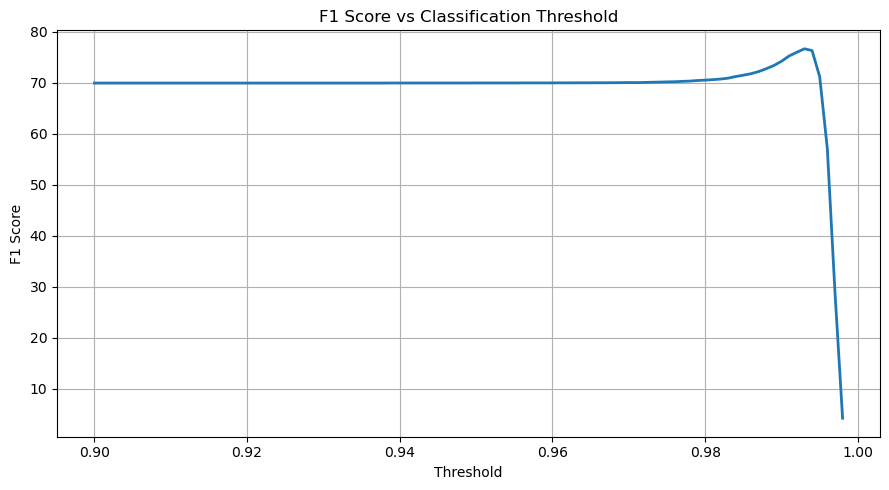

In [30]:
f1_threshold_histogram_fig = plot_f1_vs_threshold(threshold_results_df)
f1_threshold_histogram_fig.show()

Print top 5 results

In [31]:
sorted_threshold_results_df = threshold_results_df.sort_values("f1", ascending=False)
top5_results = sorted_threshold_results_df.head(5)

print("Top 5 thresholds by F1:")
print(top5_results)

Top 5 thresholds by F1:
    threshold  accuracy  precision  recall     f1
93      0.993     71.89      69.30   85.67  76.62
94      0.994     74.12      75.18   77.42  76.28
92      0.992     69.08      65.27   90.79  75.94
91      0.991     66.62      62.58   94.27  75.22
90      0.990     64.12      60.48   95.90  74.18


Pick the best result and compute y_pred

In [32]:
top_threshold = top5_results.iloc[0]["threshold"]

# Evaluate the model

In [33]:
result_df = compute_similarities(test_data_df, model)

Processing rows: 100%|██████████| 19999/19999 [1:44:35<00:00,  3.19it/s]

--- Execution Time: 6275.66 seconds ---


In [34]:
y_true = result_df['actual_result']
y_pred = (result_df["cosine_similarity"] >= top_threshold).astype(int).values

best_accuracy, best_precision, best_recall, best_f1 = evaluate_results(y_true, y_pred)

Create the confusion matrix

Text(0.5, 1.0, 'Confusion Matrix: allenai/longformer-base-4096')

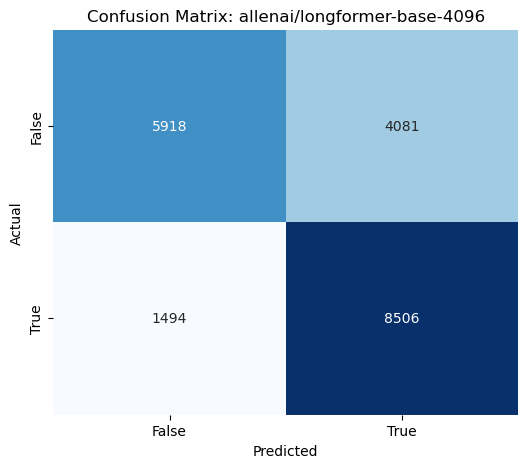

In [35]:
labels = [False, True] 
cm = confusion_matrix(y_true, y_pred, labels=labels)

cm_fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=labels, 
            yticklabels=labels, 
            ax=ax,
            cbar=False)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix: {model_id}')

Log model information + metrics + results table + confusion matrix

In [36]:
date_str = datetime.now().strftime("%Y%m%d_%H%M")
mlflow.set_experiment("/Users/jiripokorny455@gmail.com/JP_authorship_verification_dt")
with mlflow.start_run(run_name=f"{developer_initials}_{model_name}_results_{classification_type}"):
    mlflow.log_param("gpu_name", gpu_name)
    mlflow.log_param("gpu_vram_gb", gpu_vram_gb)
    
    mlflow.log_param("model_id ", model_id )
    mlflow.log_param("classification_type", classification_type)
    
    mlflow.log_param("classification_thresholds", thresholds)

    mlflow.log_table(data=result_df, artifact_file="embedding_similarity_results-test_data.json")
    mlflow.log_table(data=threshold_results_df, artifact_file="results_for_different_thresholds-training_data.json")

    mlflow.log_metric("top_threshold", top_threshold)
    mlflow.log_metric("top_f1", best_f1)
    mlflow.log_metric("top_recall", best_recall)
    mlflow.log_metric("top_precision", best_precision)
    mlflow.log_metric("top_accuracy", best_accuracy)

    mlflow.log_figure(f1_threshold_histogram_fig, "f1_results_threshold_histogram-training_data.png")
    mlflow.log_figure(cm_fig, "confusion_matrix-test_data.png")

🏃 View run JP_longformer-base-4096_results_mean_pooling_embedding at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040/runs/61bec552d7304bf2b31f2f0c3e2434c2
🧪 View experiment at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040
